<a href="https://colab.research.google.com/github/iamafifaah/LULC-Mapping-with-XGBoost/blob/main/XGBoost_LULC_Halogeo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Land Cover Mapping with XGBoost
## Introduction
Land Use/Land Cover (LULC) classification plays a critical role in understanding and managing the Earth's resources, particularly in the context of environmental monitoring and urban planning. In this project, I focused on classifying land cover into five distinct classes: Water, Forest, Cropland / Agriculture, Schrubs and Shrub, and Built-up. Leveraging advanced machine learning techniques, specifically XGBoost, I aimed to create an accurate and unbiased classification model.

The raster data for this project was sourced from the Copernicus Sentinel-2 satellite, renowned for its high-resolution imagery and extensive spectral coverage. To prepare the training data, I utilized pyspatialml Raster data from sentinel-2 to vector shapefile Geodatabase to extract raster values for each pixel, ensuring that each of the five classes had an equivalent number of data points. This careful balancing was crucial in avoiding class bias and ensuring robust model performance.

Upon training the models, I assessed their performance using a range of metrics, including Cohen's Kappa Score, Omission Error, Commission Error, Producer's Accuracy, User's Accuracy, and ROC AUC Curve. Additionally, to provide a clear representation of the classified areas, I plotted a bar graph showing the distribution of land cover classes in square kilometers, and a pie chart illustrating the proportion of surface area covered by each class.

In [ ]:
pip install rasterio

In [ ]:
pip install pyspatialml

In [ ]:
import os

# Force reinstall numpy and pandas to ensure compatibility
!pip install --force-reinstall numpy pandas

# Then reinstall pyspatialml and its dependencies
!pip install --force-reinstall pyspatialml geopandas rasterio

# Restart runtime to ensure new package versions are loaded
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 114.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.2/509.2 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.5/348.5 kB 18.5 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: tzdata
    Found existing installation: tzdata 2025.3
    Uninstalling tzdata-2025.3:
      Successfully uninstalled tzdata-2025.3
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-1.17.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.2

  Using cached pyspatialml-0.22.1-py3-none-any.whl.metadata (18 kB)
  Using cached geopandas-0.14.4-py3-none-any.whl.metadata (1.5 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.1 MB/s eta 0:00:00
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of rasterio to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 9.5 MB/s eta 0:00:00
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2025.2-p

In [ ]:
# from pyspatialml import Raster
# import os
# import matplotlib.pyplot as plt
# import pandas as pd
# import seaborn as sn
# import rasterio.plot
# import numpy as np
# import matplotlib as mpl
# import geopandas as gpd
# import numpy as np
# from tempfile import NamedTemporaryFile
# import warnings
# warnings.filterwarnings('ignore')

In [ ]:
# import rasterio
# from rasterio.plot import show
# import xgboost as xgb
# from matplotlib import pyplot as plt
# from matplotlib.colors import ListedColormap
# from matplotlib import cm
# import seaborn as sns
# import pandas as pd
# import numpy as np
# import geopandas as gpd
# from sklearn.model_selection import train_test_split

In [ ]:
from osgeo import gdal
import os
import glob
import matplotlib.pyplot as plt
from rasterio.plot import show
import rasterio.mask

## Cari lokasi file dengan glob

#### Pakai fungsi !pwd untuk mengetahui lokasi file

In [ ]:
!pwd

/content


#### Import data ke notebook dengan fungsi glob

In [ ]:
raster_list = glob.glob('/content/raster/*.tif')

#### Tampilkan data yang sudah diimport (raster list)

In [ ]:
type(raster_list)

list

In [ ]:
print(raster_list)

['/content/raster/band_12.tif', '/content/raster/band_6.tif', '/content/raster/band_5.tif', '/content/raster/band_4.tif', '/content/raster/band_2.tif', '/content/raster/band_7.tif', '/content/raster/band_8a.tif', '/content/raster/band_11.tif', '/content/raster/band_3.tif', '/content/raster/band_8.tif']


Setelah runtime di-restart, coba jalankan kembali sel `from pyspatialml import Raster`.

## Data Engineering

In [ ]:
from pyspatialml import Raster

#### Gabungkan beberapa file raster tadi menjadi raster file

In [ ]:
stack = Raster(raster_list)

In [ ]:
type(stack)

pyspatialml.raster.Raster

In [ ]:
stack.names

dict_keys(['B12', 'B6', 'B5', 'B4', 'B2', 'B7', 'B8A', 'B11', 'B3', 'B8'])

In [ ]:
# Cek dimensi (jumlah band, baris, kolom)
print(stack.shape)

(1967, 2613)


## Versi Rasterio

In [ ]:
import rasterio
import numpy as np

# List of paths to your single-band raster files (e.g., Landsat bands)
band_paths = ['/content/raster/band_4.tif', '/content/raster/band_3.tif', '/content/raster/band_2.tif']
output_path = 'stacked_image.tif'

# Read metadata from the first band to use as a template
with rasterio.open(band_paths[0]) as src0:
    meta = src0.meta.copy()

# Update the metadata for the new stacked file:
# 1. Set the band count to the total number of input bands
meta.update(count=len(band_paths))
# 2. Optionally, specify the driver (GeoTIFF is widely supported for writing)
meta.update(driver='GTiff')

# Write the new multi-band raster file
with rasterio.open(output_path, 'w', **meta) as dst:
    for id, path in enumerate(band_paths, 1):
        with rasterio.open(path) as src:
            # Read each band's data and write it to the corresponding band in the new file
            dst.write(src.read(1), id)
            # Optional: Copy band descriptions if available
            dst.set_band_description(id, src.descriptions[0] if src.descriptions else f"Band {id}")

print(f"Successfully created a {meta['count']}-band raster at: {output_path}")


In [ ]:
print(output_path)

In [ ]:
src = rasterio.open('stacked_image.tif')

In [ ]:
from rasterio.plot import show

with rasterio.open('stacked_image.tif') as src:
    # show() menangani urutan axis secara otomatis
    show(src.read([1, 2, 3]), title="RGB Plot dengan Rasterio")

In [ ]:
type(src)

#### Visualisasi Raster File



In [ ]:
print(stack.shape)

(1967, 2613)


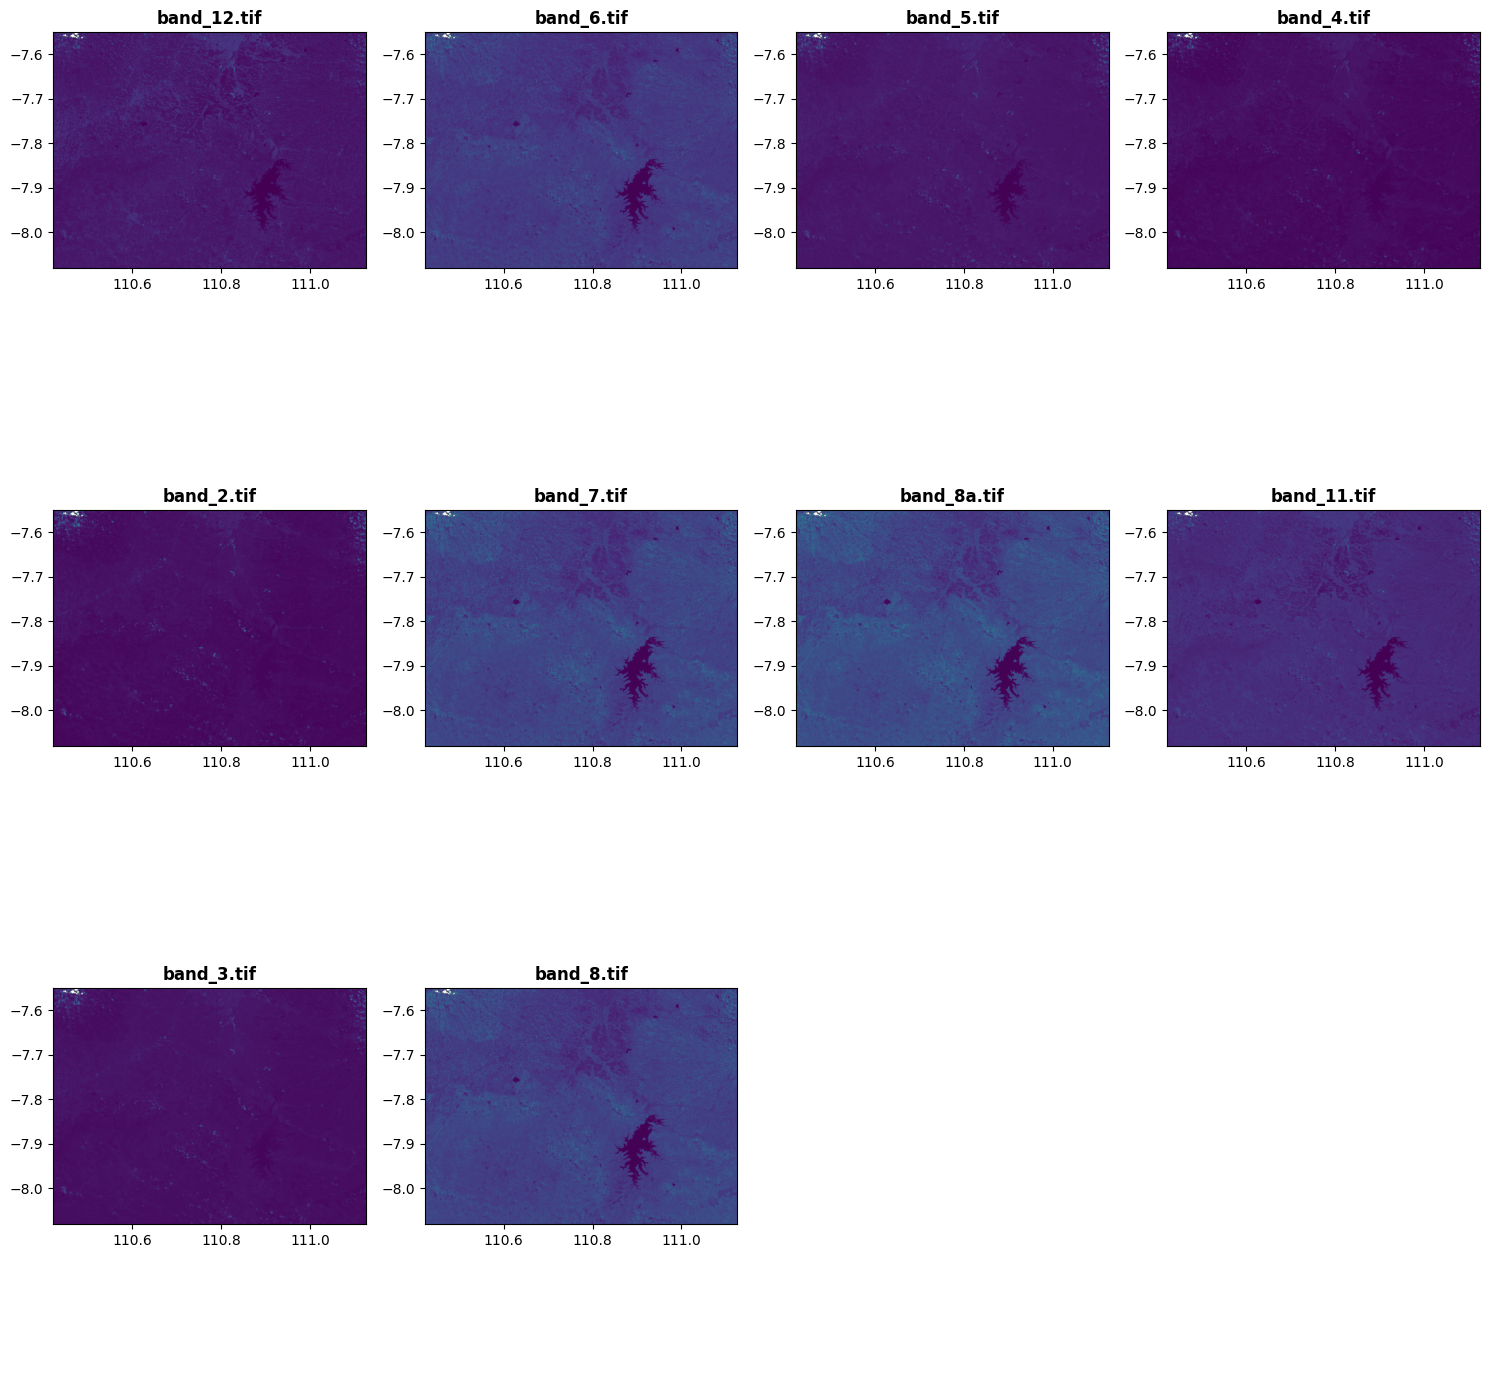

In [ ]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(15, 15))

# Flatten axes agar bisa diakses satu per satu dengan index tunggal
axes = axes.flatten()

for i, path in enumerate(raster_list):
    with rasterio.open(path) as src:
        filename = os.path.basename(path)
        show(src, ax=axes[i], title=filename)

# Turn off empty subplots if any
for j in range(len(raster_list), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
print(raster_list)

['/content/raster/band_12.tif', '/content/raster/band_6.tif', '/content/raster/band_5.tif', '/content/raster/band_4.tif', '/content/raster/band_2.tif', '/content/raster/band_7.tif', '/content/raster/band_8a.tif', '/content/raster/band_11.tif', '/content/raster/band_3.tif', '/content/raster/band_8.tif']


In [ ]:
pip install geopandas

Cek directory

In [ ]:
!pwd

/content


#### Import data Vector

In [ ]:
import geopandas as gpd

In [ ]:
sampling = r'/content/training/training.shp'

In [ ]:
sampling = gpd.read_file(sampling)

#### cek kondisi dataset

In [ ]:
sampling.head()

,class,geometry
0,0,POINT (111.03947 -7.78462)
1,0,POINT (111.03372 -7.79415)
2,0,POINT (111.02599 -7.79160)
3,0,POINT (111.06573 -7.77833)
4,0,POINT (111.06436 -7.77552)


In [ ]:
sampling.index.name = 'geometry_idx'

In [ ]:
sampling.head()

,class,geometry
geometry_idx,,
0,0,POINT (111.03947 -7.78462)
1,0,POINT (111.03372 -7.79415)
2,0,POINT (111.02599 -7.79160)
3,0,POINT (111.06573 -7.77833)
4,0,POINT (111.06436 -7.77552)


In [ ]:
# 1. Definisikan mapping labelnya
class_names = {
    0: 'forest',
    1: 'water',
    2: 'agriculture',
    3: 'shrubs_and_scrub',
    4: 'built-up'
}

# 2. Buat kolom baru bernama 'landcover' (atau nama lain bebas)
sampling['landcover'] = sampling['class'].map(class_names)

In [ ]:
# Cek hasilnya
print(sampling.head())

              class                    geometry landcover
geometry_idx                                             
0                 0  POINT (111.03947 -7.78462)    forest
1                 0  POINT (111.03372 -7.79415)    forest
2                 0  POINT (111.02599 -7.79160)    forest
3                 0  POINT (111.06573 -7.77833)    forest
4                 0  POINT (111.06436 -7.77552)    forest


<Axes: >

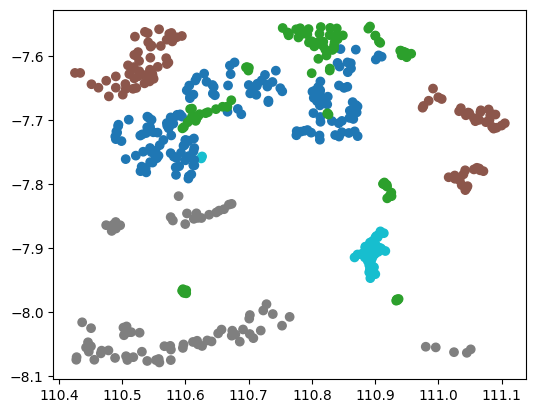

In [ ]:
sampling.plot('landcover')

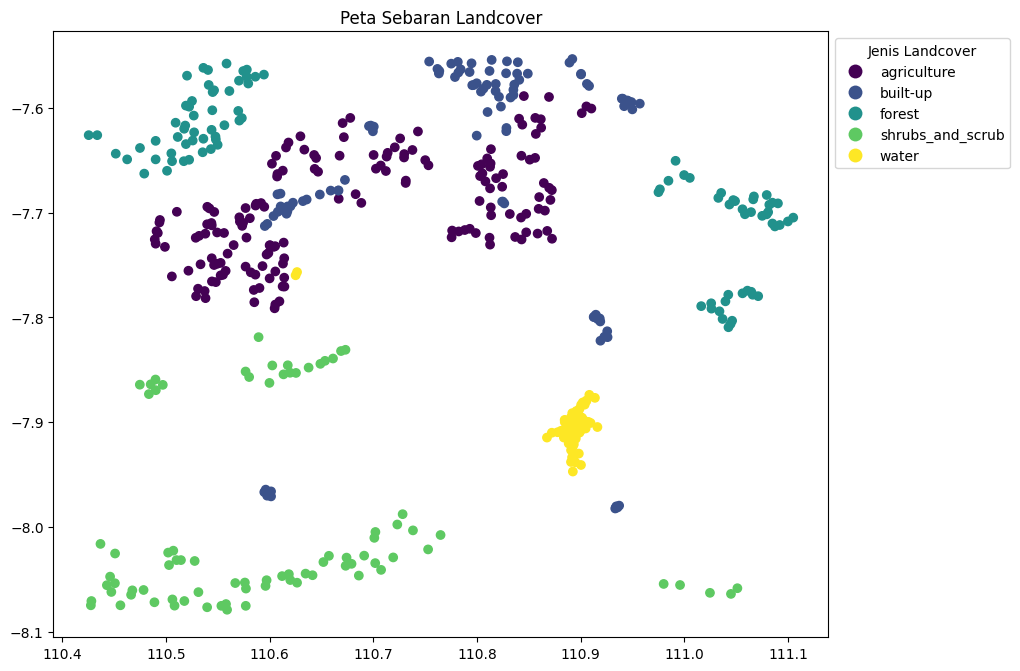

In [ ]:
import matplotlib.pyplot as plt

# 1. Tentukan ukuran gambar
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# 2. Plot data dengan pengaturan legenda
sampling.plot(
    column='landcover',
    ax=ax,
    legend=True,
    legend_kwds={
        'loc': 'upper left',       # Posisi legenda
        'bbox_to_anchor': (1, 1),   # Menggeser legenda ke luar frame peta
        'title': 'Jenis Landcover'  # Judul legenda
    },
    cmap='viridis'                  # Pilihan skema warna (contoh: viridis, tab10, jet)
)

# Tambahkan judul dan label jika perlu
plt.title('Peta Sebaran Landcover')
plt.show()

In [ ]:
sampling.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
sampling.head()

,class,geometry,landcover
geometry_idx,,,
0,0,POINT (111.03947 -7.78462),forest
1,0,POINT (111.03372 -7.79415),forest
2,0,POINT (111.02599 -7.79160),forest
3,0,POINT (111.06573 -7.77833),forest
4,0,POINT (111.06436 -7.77552),forest


In [ ]:
stack.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [ ]:
extracted = stack.extract_vector(sampling)

In [ ]:
extracted.head()

,,B12,B6,B5,B4,B2,B7,B8A,B11,B3,B8,geometry
pixel_idx,geometry_idx,,,,,,,,,,,
0,0,0.08305,0.24835,0.08420,0.02830,0.02965,0.29755,0.32340,0.17915,0.05005,0.29515,POINT (111.03947 -7.78462)
1,1,0.09005,0.26005,0.08815,0.03520,0.03055,0.31025,0.33375,0.19085,0.05455,0.30765,POINT (111.03372 -7.79415)
2,2,0.07310,0.22575,0.07275,0.02705,0.02470,0.28225,0.30125,0.15800,0.04350,0.26020,POINT (111.02599 -7.79160)
3,3,0.06915,0.24275,0.07865,0.03105,0.02835,0.30165,0.33365,0.16180,0.04890,0.29525,POINT (111.06573 -7.77833)
4,4,0.07545,0.23585,0.07610,0.02805,0.02645,0.29250,0.31975,0.16500,0.04355,0.29190,POINT (111.06436 -7.77552)


In [ ]:
extracted = extracted.reset_index()
sampling = sampling.reset_index()

dataset = extracted.merge(sampling[['geometry_idx', 'class', 'landcover']], on='geometry_idx', how='left')

In [ ]:
dataset.head()

,pixel_idx,geometry_idx,B12,B6,B5,B4,B2,B7,B8A,B11,B3,B8,geometry,class,landcover
0,0,0,0.08305,0.24835,0.08420,0.02830,0.02965,0.29755,0.32340,0.17915,0.05005,0.29515,POINT (111.03947 -7.78462),0,forest
1,1,1,0.09005,0.26005,0.08815,0.03520,0.03055,0.31025,0.33375,0.19085,0.05455,0.30765,POINT (111.03372 -7.79415),0,forest
2,2,2,0.07310,0.22575,0.07275,0.02705,0.02470,0.28225,0.30125,0.15800,0.04350,0.26020,POINT (111.02599 -7.79160),0,forest
3,3,3,0.06915,0.24275,0.07865,0.03105,0.02835,0.30165,0.33365,0.16180,0.04890,0.29525,POINT (111.06573 -7.77833),0,forest
4,4,4,0.07545,0.23585,0.07610,0.02805,0.02645,0.29250,0.31975,0.16500,0.04355,0.29190,POINT (111.06436 -7.77552),0,forest


In [ ]:
# dataset.drop['landcover']

In [ ]:
dataset.index.name = 'index'

In [ ]:
dataset.head()

,pixel_idx,geometry_idx,B12,B6,B5,B4,B2,B7,B8A,B11,B3,B8,geometry,class,landcover
index,,,,,,,,,,,,,,,
0,0,0,0.08305,0.24835,0.08420,0.02830,0.02965,0.29755,0.32340,0.17915,0.05005,0.29515,POINT (111.03947 -7.78462),0,forest
1,1,1,0.09005,0.26005,0.08815,0.03520,0.03055,0.31025,0.33375,0.19085,0.05455,0.30765,POINT (111.03372 -7.79415),0,forest
2,2,2,0.07310,0.22575,0.07275,0.02705,0.02470,0.28225,0.30125,0.15800,0.04350,0.26020,POINT (111.02599 -7.79160),0,forest
3,3,3,0.06915,0.24275,0.07865,0.03105,0.02835,0.30165,0.33365,0.16180,0.04890,0.29525,POINT (111.06573 -7.77833),0,forest
4,4,4,0.07545,0.23585,0.07610,0.02805,0.02645,0.29250,0.31975,0.16500,0.04355,0.29190,POINT (111.06436 -7.77552),0,forest


In [ ]:
dataset.drop(['pixel_idx','geometry_idx', 'geometry'], axis = 1, inplace = True)

In [ ]:
dataset.head()

,B12,B6,B5,B4,B2,B7,B8A,B11,B3,B8,class,landcover
index,,,,,,,,,,,,
0,0.08305,0.24835,0.08420,0.02830,0.02965,0.29755,0.32340,0.17915,0.05005,0.29515,0,forest
1,0.09005,0.26005,0.08815,0.03520,0.03055,0.31025,0.33375,0.19085,0.05455,0.30765,0,forest
2,0.07310,0.22575,0.07275,0.02705,0.02470,0.28225,0.30125,0.15800,0.04350,0.26020,0,forest
3,0.06915,0.24275,0.07865,0.03105,0.02835,0.30165,0.33365,0.16180,0.04890,0.29525,0,forest
4,0.07545,0.23585,0.07610,0.02805,0.02645,0.29250,0.31975,0.16500,0.04355,0.29190,0,forest


In [ ]:
Y = dataset[['class']]

In [ ]:
Y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523 entries, 0 to 522
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   class   523 non-null    int64
dtypes: int64(1)
memory usage: 4.2 KB


In [ ]:
x = dataset[['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']]

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523 entries, 0 to 522
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   B2      523 non-null    float64
 1   B3      523 non-null    float64
 2   B4      523 non-null    float64
 3   B5      523 non-null    float64
 4   B6      523 non-null    float64
 5   B7      523 non-null    float64
 6   B8      523 non-null    float64
 7   B8A     523 non-null    float64
 8   B11     523 non-null    float64
 9   B12     523 non-null    float64
dtypes: float64(10)
memory usage: 41.0 KB


In [ ]:
import seaborn as sns

In [ ]:
def count_categories(feature):
  print(sampling[feature].value_counts())
  plt.figure(figsize=(2, 2))
  sns.countplot(
      x=feature,
      data=dataset,
      palette='Set2'
  )

landcover
agriculture         162
built-up            100
forest               94
water                85
shrubs_and_scrub     82
Name: count, dtype: int64


/tmp/ipython-input-4222741041.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


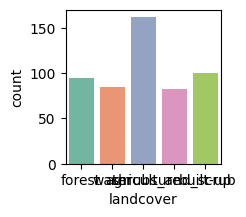

In [ ]:
count_categories('landcover')

class
2    162
4    100
0     94
1     85
3     82
Name: count, dtype: int64


/tmp/ipython-input-4222741041.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


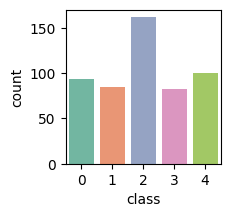

In [ ]:
count_categories('class')

In [ ]:
#### Basic Important Modules ####
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("ggplot")
plt.rcParams['figure.figsize'] = (12, 8)
import seaborn as sns
sns.set(style='whitegrid', color_codes=True)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
dataset.head()

,B12,B6,B5,B4,B2,B7,B8A,B11,B3,B8,class,landcover
index,,,,,,,,,,,,
0,0.08305,0.24835,0.08420,0.02830,0.02965,0.29755,0.32340,0.17915,0.05005,0.29515,0,forest
1,0.09005,0.26005,0.08815,0.03520,0.03055,0.31025,0.33375,0.19085,0.05455,0.30765,0,forest
2,0.07310,0.22575,0.07275,0.02705,0.02470,0.28225,0.30125,0.15800,0.04350,0.26020,0,forest
3,0.06915,0.24275,0.07865,0.03105,0.02835,0.30165,0.33365,0.16180,0.04890,0.29525,0,forest
4,0.07545,0.23585,0.07610,0.02805,0.02645,0.29250,0.31975,0.16500,0.04355,0.29190,0,forest


In [ ]:
dataset.drop(['landcover'], axis = 1, inplace = True)

In [ ]:
dataset.head()

,B12,B6,B5,B4,B2,B7,B8A,B11,B3,B8,class
index,,,,,,,,,,,
0,0.08305,0.24835,0.08420,0.02830,0.02965,0.29755,0.32340,0.17915,0.05005,0.29515,0
1,0.09005,0.26005,0.08815,0.03520,0.03055,0.31025,0.33375,0.19085,0.05455,0.30765,0
2,0.07310,0.22575,0.07275,0.02705,0.02470,0.28225,0.30125,0.15800,0.04350,0.26020,0
3,0.06915,0.24275,0.07865,0.03105,0.02835,0.30165,0.33365,0.16180,0.04890,0.29525,0
4,0.07545,0.23585,0.07610,0.02805,0.02645,0.29250,0.31975,0.16500,0.04355,0.29190,0


In [ ]:
# Ambil semua nama kolom
cols = list(dataset.columns)

# Pindahkan 'class' ke depan
cols.insert(0, cols.pop(cols.index('class')))

# Terapkan urutan baru ke dataset
dataset = dataset[cols]

# Cek hasil
print(dataset.head())

       class      B12       B6       B5       B4       B2       B7      B8A  \
index                                                                         
0          0  0.08305  0.24835  0.08420  0.02830  0.02965  0.29755  0.32340   
1          0  0.09005  0.26005  0.08815  0.03520  0.03055  0.31025  0.33375   
2          0  0.07310  0.22575  0.07275  0.02705  0.02470  0.28225  0.30125   
3          0  0.06915  0.24275  0.07865  0.03105  0.02835  0.30165  0.33365   
4          0  0.07545  0.23585  0.07610  0.02805  0.02645  0.29250  0.31975   

           B11       B3       B8  
index                             
0      0.17915  0.05005  0.29515  
1      0.19085  0.05455  0.30765  
2      0.15800  0.04350  0.26020  
3      0.16180  0.04890  0.29525  
4      0.16500  0.04355  0.29190  


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523 entries, 0 to 522
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   class   523 non-null    int64  
 1   B12     523 non-null    float64
 2   B6      523 non-null    float64
 3   B5      523 non-null    float64
 4   B4      523 non-null    float64
 5   B2      523 non-null    float64
 6   B7      523 non-null    float64
 7   B8A     523 non-null    float64
 8   B11     523 non-null    float64
 9   B3      523 non-null    float64
 10  B8      523 non-null    float64
dtypes: float64(10), int64(1)
memory usage: 45.1 KB


In [ ]:
# 1. Ambil semua nama kolom kecuali 'class'
band_cols = [c for c in dataset.columns if c != 'class']

# 2. Urutkan band_cols berdasarkan angka di dalam namanya
# Kita hapus karakter 'B' dan 'A' lalu ubah ke integer untuk sorting
band_cols.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))

# 3. Gabungkan kembali: 'class' di depan + band yang sudah urut
new_order = ['class'] + band_cols

# 4. Terapkan ke dataset
dataset = dataset[new_order]

# Cek hasil
print(dataset.head())

       class       B2       B3       B4       B5       B6       B7      B8A  \
index                                                                         
0          0  0.02965  0.05005  0.02830  0.08420  0.24835  0.29755  0.32340   
1          0  0.03055  0.05455  0.03520  0.08815  0.26005  0.31025  0.33375   
2          0  0.02470  0.04350  0.02705  0.07275  0.22575  0.28225  0.30125   
3          0  0.02835  0.04890  0.03105  0.07865  0.24275  0.30165  0.33365   
4          0  0.02645  0.04355  0.02805  0.07610  0.23585  0.29250  0.31975   

            B8      B11      B12  
index                             
0      0.29515  0.17915  0.08305  
1      0.30765  0.19085  0.09005  
2      0.26020  0.15800  0.07310  
3      0.29525  0.16180  0.06915  
4      0.29190  0.16500  0.07545  


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523 entries, 0 to 522
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   class   523 non-null    int64  
 1   B2      523 non-null    float64
 2   B3      523 non-null    float64
 3   B4      523 non-null    float64
 4   B5      523 non-null    float64
 5   B6      523 non-null    float64
 6   B7      523 non-null    float64
 7   B8A     523 non-null    float64
 8   B8      523 non-null    float64
 9   B11     523 non-null    float64
 10  B12     523 non-null    float64
dtypes: float64(10), int64(1)
memory usage: 45.1 KB


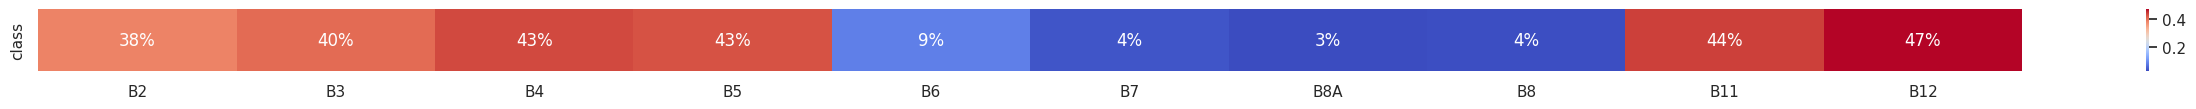

In [ ]:
plt.figure(figsize=(32, .8))
sns.heatmap(
    data=dataset.corr('kendall').iloc[:1, 1:],
    annot=True,
    fmt='.0%',
    cmap='coolwarm'
);

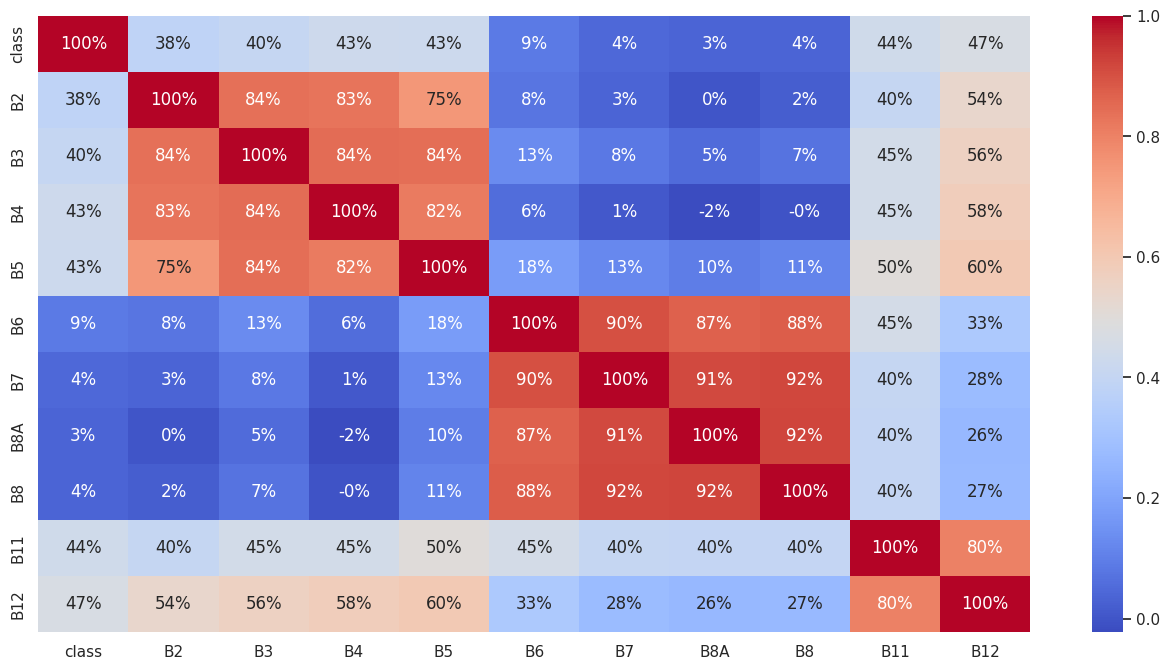

In [ ]:
# Numerical Input - Categorical Output
# Kendall's Method
plt.figure(figsize=(16, 8))
sns.heatmap(
    data=dataset.corr('kendall'),
    annot=True,
    fmt='.0%',
    cmap='coolwarm'
);

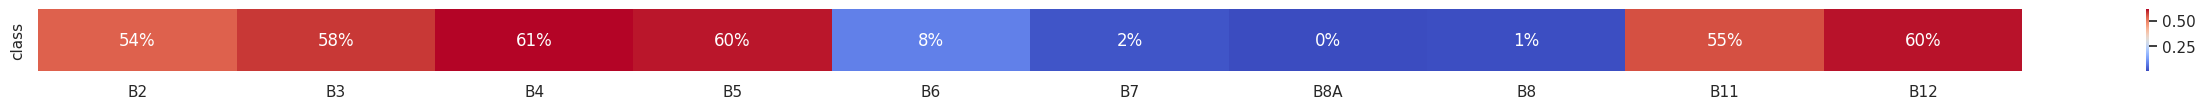

In [ ]:
plt.figure(figsize=(32, .8))
sns.heatmap(
    data=dataset.corr('spearman').iloc[:1, 1:],
    annot=True,
    fmt='.0%',
    cmap='coolwarm'
);

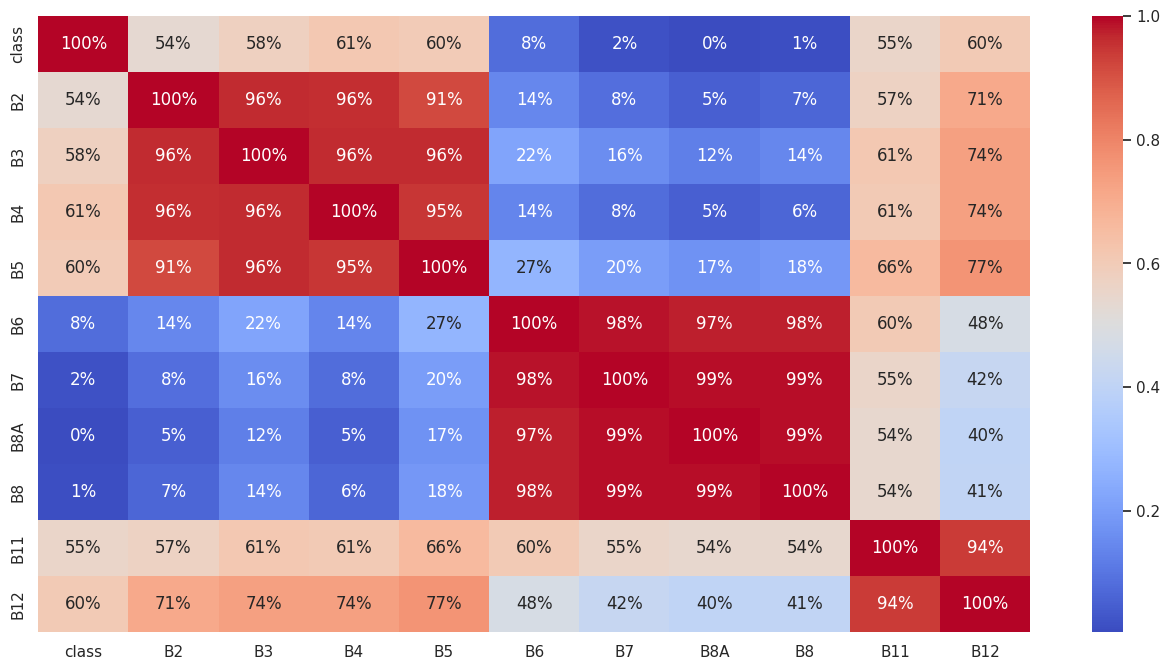

In [ ]:
# Numerical Input - Categorical Output
# Spearman Method
plt.figure(figsize=(16, 8))
sns.heatmap(
    data=dataset.corr('spearman'),
    annot=True,
    fmt='.0%',
    cmap='coolwarm'
);

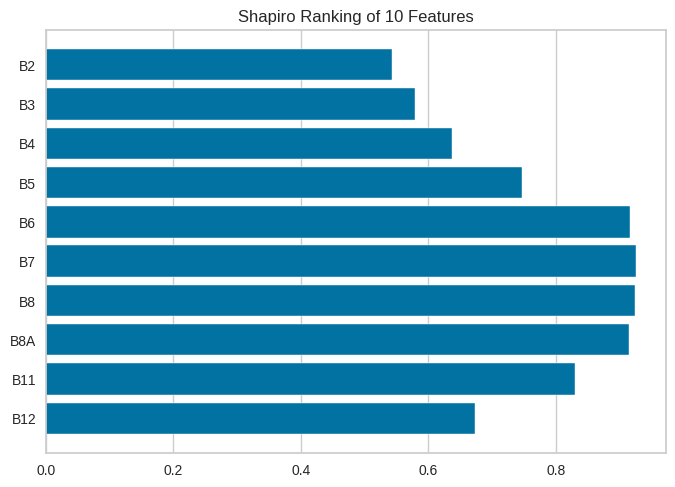

<Axes: title={'center': 'Shapiro Ranking of 10 Features'}>

In [ ]:
from yellowbrick.features import Rank1D

# Instantiate the 1D visualizer with the Sharpiro ranking algorithm
visualizer = Rank1D(algorithm='shapiro', features= x.columns)
visualizer.fit(x, Y)           # Fit the data to the visualizer
visualizer.transform(x.values);        # Transform the data
visualizer.show()              # Finalize and render the figure

In [ ]:
from scipy.stats import shapiro
# normality test
def normality_test_shapiro(feature):
  stat, p = shapiro(x[feature].values)
  print('Statistics=%.3f, p=%.3f' % (stat, p))
  # interpret
  alpha = 0.05
  if p > alpha:
    print('Sample looks Gaussian (fail to reject H0)')
  else:
    print('Sample does not look Gaussian (reject H0)')

In [ ]:
for feature in x.columns:
  normality_test_shapiro(feature)

Statistics=0.543, p=0.000
Sample does not look Gaussian (reject H0)
Statistics=0.579, p=0.000
Sample does not look Gaussian (reject H0)
Statistics=0.638, p=0.000
Sample does not look Gaussian (reject H0)
Statistics=0.747, p=0.000
Sample does not look Gaussian (reject H0)
Statistics=0.916, p=0.000
Sample does not look Gaussian (reject H0)
Statistics=0.926, p=0.000
Sample does not look Gaussian (reject H0)
Statistics=0.924, p=0.000
Sample does not look Gaussian (reject H0)
Statistics=0.915, p=0.000
Sample does not look Gaussian (reject H0)
Statistics=0.830, p=0.000
Sample does not look Gaussian (reject H0)
Statistics=0.672, p=0.000
Sample does not look Gaussian (reject H0)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, Y, test_size=0.3, random_state=42, stratify = Y)

In [ ]:
import xgboost as xgb

In [ ]:
model_xgboost = xgb.XGBClassifier(objective = "multi:softprob", random_state = 42, verbosity = 3, n_estimators = 100, max_depth = 10, n_thread = 8, n_jobs = 8, learning_rate = 0.01)
model_xgboost.fit(x_train, y_train)

[13:07:30] ======== Monitor (0): HostSketchContainer ========
[13:07:30] AllReduce: 0.000512s, 1 calls @ 512us

[13:07:30] MakeCuts: 0.000622s, 1 calls @ 622us

[13:07:30] INFO: /workspace/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (366, 10, 3660).
[13:07:30] DEBUG: /workspace/src/gbm/gbtree.cc:127: Using tree method: 0
[13:07:30] ======== Monitor (0): GBTree ========
[13:07:30] BoostNewTrees: 0.427231s, 100 calls @ 427231us

[13:07:30] CommitModel: 0.00013s, 100 calls @ 130us

[13:07:30] ======== Monitor (0): HistUpdater ========
[13:07:30] BuildHistogram: 0.055802s, 2604 calls @ 55802us

[13:07:30] EvaluateSplits: 0.305451s, 3104 calls @ 305451us

[13:07:30] InitData: 0.005029s, 500 calls @ 5029us

[13:07:30] InitRoot: 0.050955s, 500 calls @ 50955us

[13:07:30] LeafPartition: 7.1e-05s, 500 calls @ 71us

[13:07:30] UpdatePosition: 0.029376s, 2604 calls @ 29376us

[13:07:30] UpdatePredictionCache: 0.003435s, 500 calls @ 3435us

[13:07:30] UpdateTree

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [ ]:
train = model_xgboost.fit(x_train, y_train)

[13:07:39] ======== Monitor (0): HostSketchContainer ========
[13:07:39] AllReduce: 0.000239s, 1 calls @ 239us

[13:07:39] MakeCuts: 0.000299s, 1 calls @ 299us

[13:07:39] INFO: /workspace/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (366, 10, 3660).
[13:07:39] DEBUG: /workspace/src/gbm/gbtree.cc:127: Using tree method: 0
[13:07:40] ======== Monitor (0): GBTree ========
[13:07:40] BoostNewTrees: 0.327351s, 100 calls @ 327351us

[13:07:40] CommitModel: 9.4e-05s, 100 calls @ 94us

[13:07:40] ======== Monitor (0): HistUpdater ========
[13:07:40] BuildHistogram: 0.041585s, 2604 calls @ 41585us

[13:07:40] EvaluateSplits: 0.24102s, 3104 calls @ 241020us

[13:07:40] InitData: 0.002925s, 500 calls @ 2925us

[13:07:40] InitRoot: 0.037631s, 500 calls @ 37631us

[13:07:40] LeafPartition: 7.4e-05s, 500 calls @ 74us

[13:07:40] UpdatePosition: 0.018679s, 2604 calls @ 18679us

[13:07:40] UpdatePredictionCache: 0.002557s, 500 calls @ 2557us

[13:07:40] UpdateTree: 

In [ ]:
y_pred_xgb = model_xgboost.predict(x_test)

[13:07:46] DEBUG: /workspace/src/gbm/gbtree.cc:127: Using tree method: 0


## Akurasi
1. Import packages

In [ ]:
from yellowbrick.model_selection import CVScores
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

#### Precision, Recall, F1-Score and Support (User Accuracy and Producer Accuracy)

In [ ]:
print(classification_report(y_test, y_pred_xgb, target_names = ['forest',
    'water',
    'agriculture',
    'shrubs_and_scrub',
    'built-up']))

NameError: name 'classification_report' is not defined

## Overall Accuracy

In [ ]:
print(accuracy_score(y_test, y_pred_xgb))

0.8343949044585988


## Confusion Matrix

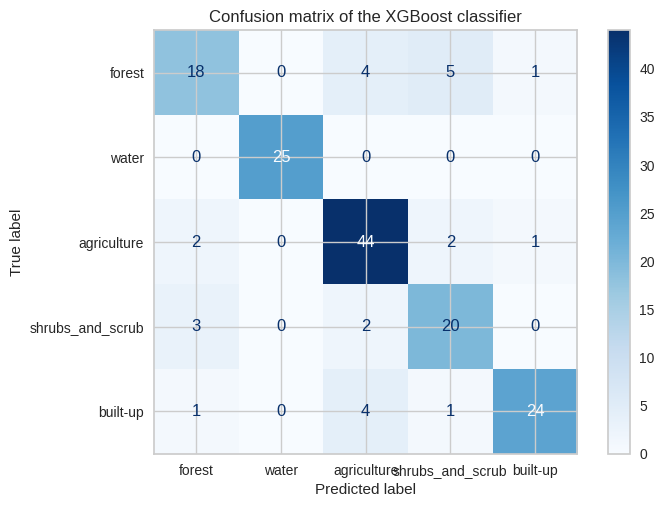

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb,
                                        cmap="Blues",
                                        display_labels=['forest',
    'water',
    'agriculture',
    'shrubs_and_scrub',
    'built-up'])

plt.title('Confusion matrix of the XGBoost classifier')
plt.show()

## ROC AUC

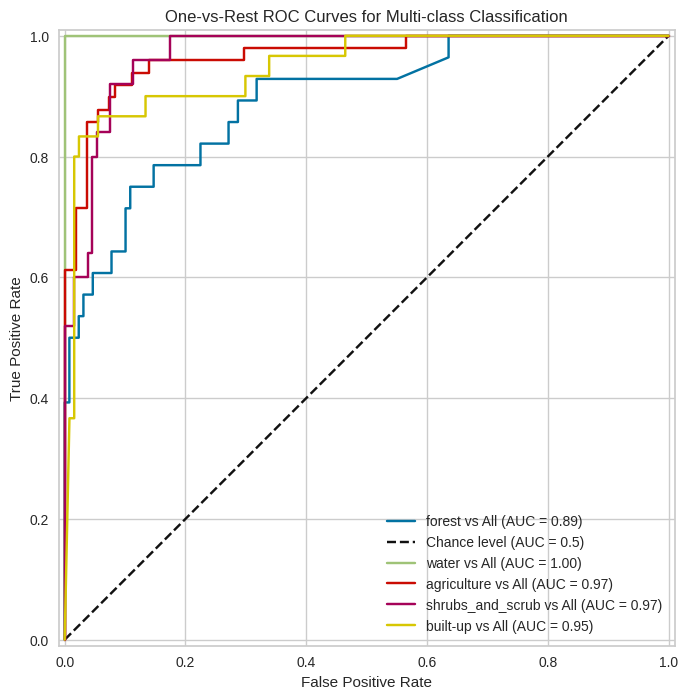

In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)
class_labels = [class_names[i] for i in sorted(class_names.keys())]
y_score = model_xgboost.predict_proba(x_test)
plt.figure(figsize=(10, 8))
for i in range(len(class_labels)):
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i], # True binary labels for current class
        y_score[:, i],        # Predicted probabilities for current class
        name=f'{class_labels[i]} vs All',
        ax=plt.gca(),          # Plot on the current axes
        plot_chance_level=True if i == 0 else False # Only plot chance level once
    )
plt.title('One-vs-Rest ROC Curves for Multi-class Classification')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import make_scorer, accuracy_score

In [ ]:
from sklearn import metrics

## Kappa Score

In [ ]:
from sklearn.metrics import cohen_kappa_score
print(cohen_kappa_score(y_test, y_pred_xgb))

0.7876833454696764


In [ ]:
band_2 = rasterio.open('/content/raster/band_2.tif')
band_3 = rasterio.open('/content/raster/band_3.tif')
band_4 = rasterio.open('/content/raster/band_4.tif')
band_5 = rasterio.open('/content/raster/band_5.tif')
band_6 = rasterio.open('/content/raster/band_6.tif')
band_7 = rasterio.open('/content/raster/band_7.tif')
band_8 = rasterio.open('/content/raster/band_8.tif')
band_8a = rasterio.open('/content/raster/band_8a.tif')
band_11 = rasterio.open('/content/raster/band_11.tif')
band_12 = rasterio.open('/content/raster/band_12.tif')

In [ ]:
import numpy as np

# Baca data dari masing-masing band (menggunakan .read(1))
b2 = band_2.read(1)
b3 = band_3.read(1)
b4 = band_4.read(1)
b5 = band_5.read(1)
b6 = band_6.read(1)
b7 = band_7.read(1)
b8 = band_8.read(1)
b8a = band_8a.read(1)
b11 = band_11.read(1)
b12 = band_12.read(1)

# Stack secara berurutan (misal: B2, B3, B4, B8)
# Hasilnya adalah array dengan bentuk (4, height, width)
stacked_img = np.stack([b2, b3, b4, b5, b6, b7, b8, b8a, b11, b12])

print(stacked_img.shape) # Output: (4, baris, kolom)

(10, 1967, 2613)


In [ ]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['yellow', 'red', 'lime', 'cyan'])

### Transpose matrix shape bentuk dataset

In [ ]:
stacked_img.shape

(10, 1967, 2613)

In [ ]:
import numpy as np

# 1. Pastikan urutan dimensi adalah (Bands, Height, Width)
# Jika shape saat ini adalah (10, 1967, 2613), maka sudah benar.
# Jika tidak, gunakan: stacked_img = stacked_img.transpose(2, 0, 1) atau sesuaikan.

bands, rows, cols = stacked_img.shape

# 2. Reshape dari 3D ke 2D
# Kita pindahkan dimensi band ke belakang, lalu ratakan (flatten) baris & kolomnya
# Hasilnya akan menjadi: (Jumlah_Piksel, 10)
img_reshaped = stacked_img.reshape(bands, -1).T

print(f"Bentuk data untuk prediksi: {img_reshaped.shape}")
# Seharusnya sekarang: (5140000+, 10)

# 3. Lakukan prediksi
array_pred = model_xgboost.predict(img_reshaped)

# 4. Kembalikan hasil prediksi ke bentuk peta (2D)
result_map = array_pred.reshape(rows, cols)

# Cek hasil akhir
print(f"Bentuk peta hasil: {result_map.shape}")

Bentuk data untuk prediksi: (5139771, 10)
Bentuk peta hasil: (1967, 2613)


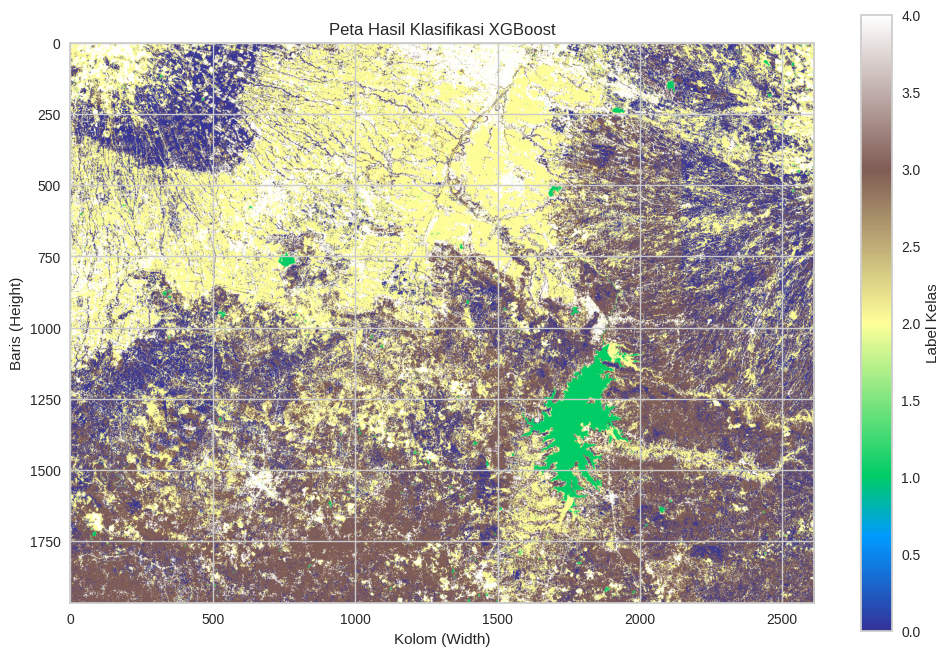

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definisikan warna untuk setiap kelas (sesuaikan jumlahnya dengan kelas Anda)
# Misal ada 5 kelas, kita bisa gunakan colormap 'terrain', 'viridis', atau custom
plt.figure(figsize=(12, 8))

# 2. Tampilkan hasil prediksi yang sudah di-reshape tadi
# interpolation='nearest' menjaga agar pixel tidak terlihat blur
img_plot = plt.imshow(result_map, cmap='terrain')

# 3. Tambahkan Colorbar untuk keterangan kelas (0, 1, 2, 3, 4)
plt.colorbar(img_plot, label='Label Kelas')

plt.title("Peta Hasil Klasifikasi XGBoost")
plt.xlabel("Kolom (Width)")
plt.ylabel("Baris (Height)")
plt.show()

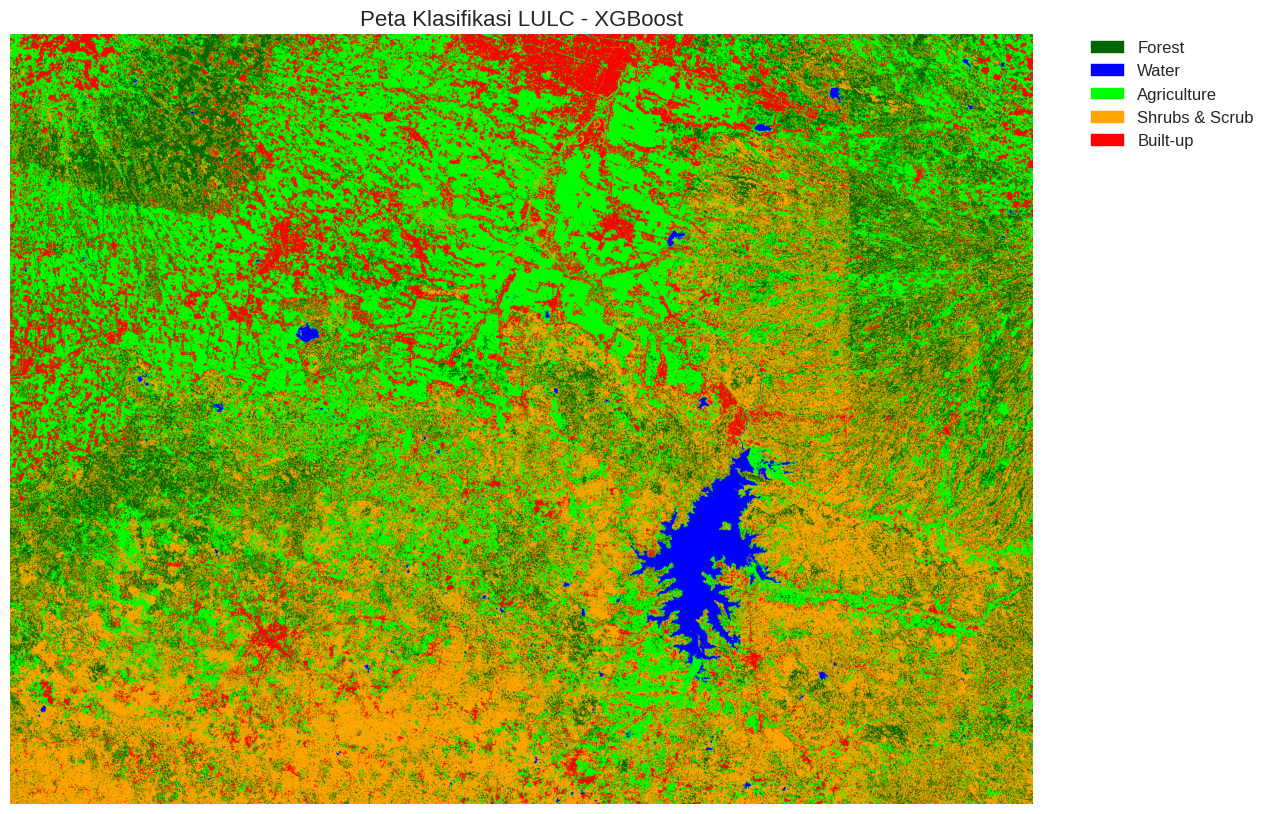

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import numpy as np

# 1. Definisikan mapping warna dan nama
# 0: Forest (Hijau Tua), 1: Water (Biru), 2: Agriculture (Hijau Muda),
# 3: Shrubs (Orange), 4: Built-up (Merah)
colors = ['darkgreen', 'blue', 'lime', 'orange', 'red']
class_names = ['Forest', 'Water', 'Agriculture', 'Shrubs & Scrub', 'Built-up']

# 2. Buat Colormap kustom
cmap_custom = ListedColormap(colors)

# 3. Plotting
plt.figure(figsize=(14, 10))

# Gunakan vmin dan vmax agar index warna tidak bergeser jika ada kelas yang absen
img_plot = plt.imshow(result_map, cmap=cmap_custom, vmin=0, vmax=4)

# 4. Membuat Legend Manual (Karena Colorbar kurang cocok untuk data kategorikal)
patches = [mpatches.Patch(color=colors[i], label=class_names[i]) for i in range(len(colors))]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=12)

plt.title("Peta Klasifikasi LULC - XGBoost", fontsize=16)
plt.axis('off') # Menghilangkan angka di sumbu X dan Y agar terlihat seperti peta asli
plt.show()

In [ ]:
classes, quanti_arr = np.unique(array_pred, return_counts = True)

In [ ]:
quanti_arr

array([1002962,   83871, 1728495, 1650530,  673913])

In [ ]:
areas = quanti_arr * 20 * 20 /1000000

In [ ]:
values = ['Forest','Water','Agriculture','Schrubss & Scrub', 'Built-up']

In [ ]:
data_stack = np.stack((classes, quanti_arr, areas, values))

In [ ]:
data_stack.T

array([['0', '1002962', '401.1848', 'Forest'],
       ['1', '83871', '33.5484', 'Water'],
       ['2', '1728495', '691.398', 'Agriculture'],
       ['3', '1650530', '660.212', 'Schrubss & Scrub'],
       ['4', '673913', '269.5652', 'Built-up']], dtype='<U32')

In [ ]:
df_data = pd.DataFrame(data = data_stack.T, columns = ['ClassNo', 'Qtd', 'Area (sqkm)', 'Classes'])

In [ ]:
df_data['Area (sqkm)'] = df_data['Area (sqkm)'].astype(np.float32)

In [ ]:
df_data

,ClassNo,Qtd,Area (sqkm),Classes
0,0,1002962,401.184814,Forest
1,1,83871,33.548401,Water
2,2,1728495,691.398010,Agriculture
3,3,1650530,660.211975,Schrubss & Scrub
4,4,673913,269.565186,Built-up


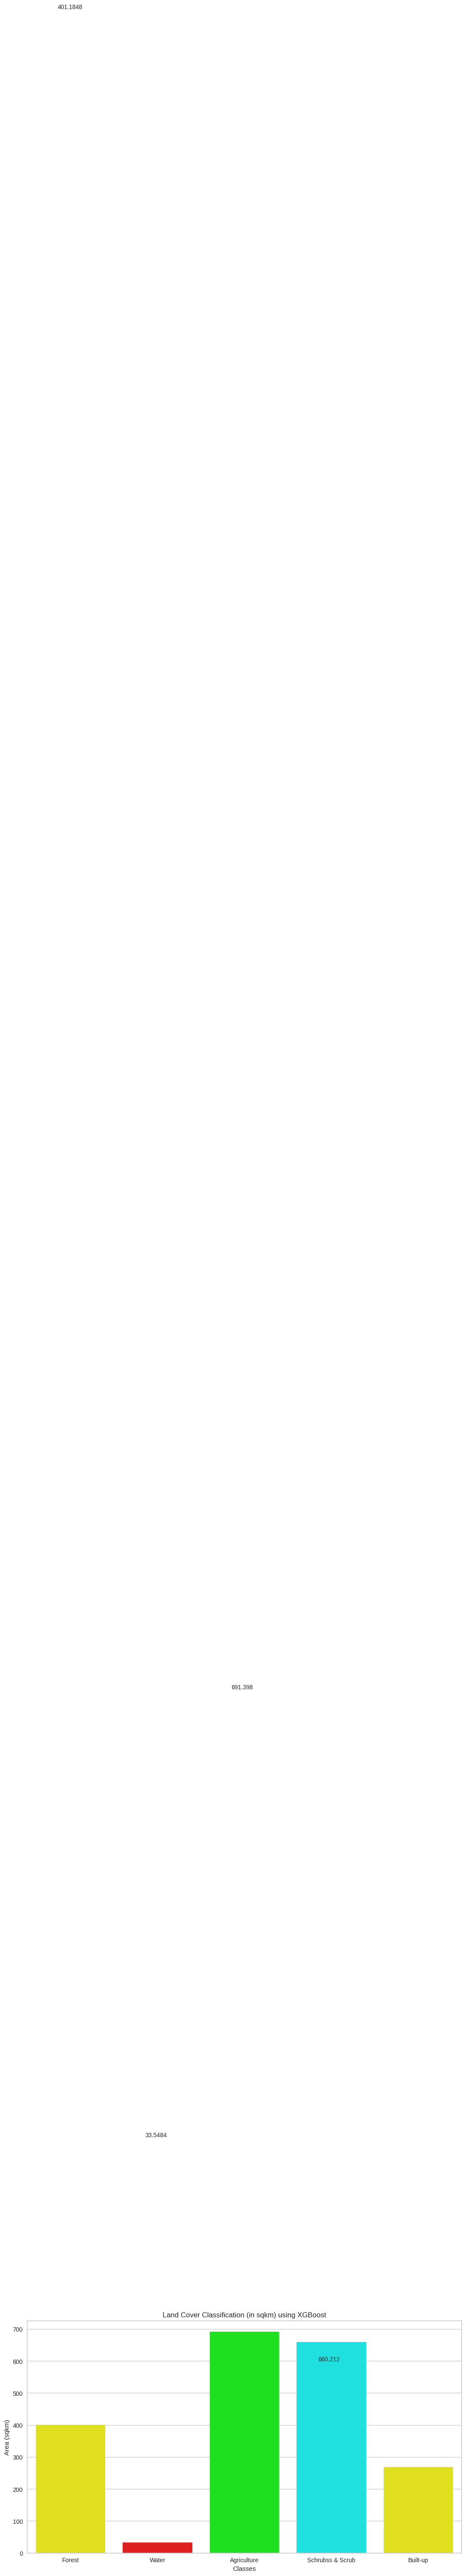

In [ ]:
fig, ax3 = plt.subplots(figsize = (13, 7))
ax1 = sns.barplot(data = df_data, x = 'Classes', y = 'Area (sqkm)', palette = cmap.colors)

plt.text(-0.15, 7950, df_data['Area (sqkm)'][0], fontsize = 10)
plt.text(0.86, 1300, df_data['Area (sqkm)'][1], fontsize = 10)
plt.text(1.85, 2700, df_data['Area (sqkm)'][2], fontsize = 10)
plt.text(2.85, 600, df_data['Area (sqkm)'][3], fontsize = 10)
plt.title('Land Cover Classification (in sqkm) using XGBoost')
plt.show()

In [ ]:
def draw_pieChart(data):
    cover = [['Forest','Water','Agriculture','Schrubss & Scrub', 'Built-up']]
    palette_color = sns.color_palette('Reds')
    explode = [0.1, 0, 0, 0]
    plt.pie(data, labels=cover, colors=['yellow', 'red', 'lime', 'cyan','orange'], explode=explode, autopct='%.0f%%')
    plt.show()

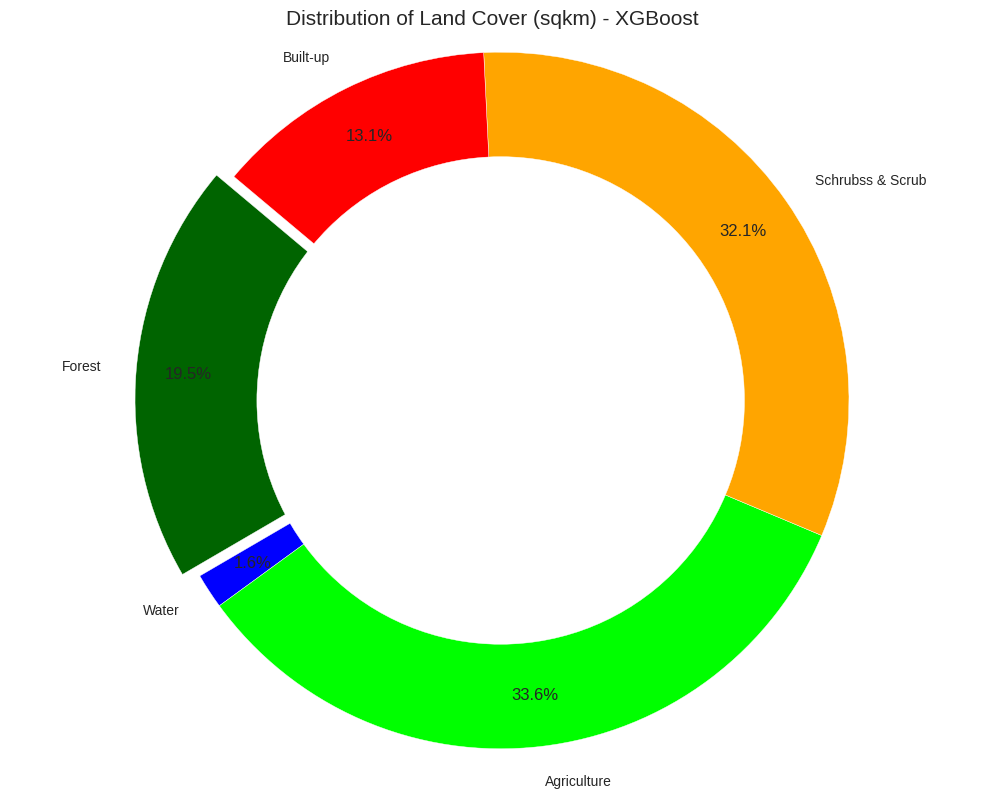

In [ ]:
import matplotlib.pyplot as plt

# 1. Siapkan data (pastikan df_data sudah berisi hasil hitungan luas)
labels = df_data['Classes']
sizes = df_data['Area (sqkm)']
# Menggunakan warna yang sama dengan colormap kustom Anda
colors = ['darkgreen', 'blue', 'lime', 'orange', 'red']

# 2. Buat Pie Chart
plt.figure(figsize=(10, 8))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%', # Menampilkan persentase dengan 1 angka di belakang koma
    startangle=140,    # Memutar posisi awal agar komposisi terlihat seimbang
    pctdistance=0.85,  # Jarak teks persentase dari pusat
    explode=(0.05, 0, 0, 0, 0) # Memberikan efek 'terpotong' pada kelas pertama (Forest)
)

# 3. Tambahkan lingkaran di tengah agar menjadi Donut Chart (Opsional, lebih modern)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Land Cover (sqkm) - XGBoost', fontsize=15)
plt.axis('equal') # Memastikan lingkaran berbentuk bulat sempurna
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Flatten hasil peta kembali ke 1D (satu kolom panjang)
result_flat = result_map.flatten()

# 2. Masukkan ke Pandas DataFrame
df_hasil = pd.DataFrame(result_flat, columns=['kelas_prediksi'])

# 3. Export ke CSV
df_hasil.to_csv("xgboost_lulc_ver2.csv", index=False)

print("Export CSV selesai!")

Export CSV selesai!


In [ ]:
# GANTI INI:
# result_map.write(r"xgboost_lulc_ver2.csv")

# MENJADI INI:
pd.DataFrame(result_map.flatten()).to_csv("xgboost_lulc_ver3.csv")

In [ ]:
# fig, ax = plt.subplots(figsize = (20,20))
# sampling.plot(column = 'landcover', cmap = cmap, legend = True, legend_kwds = {'bbox_to_anchor':(1,0.5), 'loc':'upper left', 'fontsize': 20, 'frameon': False}, ax = ax)

# # Open the stacked image again to get the src object and its transform
# stacked_img_reshaped = stacked_img.transpose(1, 2, 0).reshape(rows * cols, num_bands)
# with rasterio.open('stacked_image.tif') as src_plot:
#     show(predict_img_reshaped, transform = src_plot.transform, ax = ax)

# plt.title('Datapoints in the dataset', fontsize = '24')
# ax.axis('off')
# plt.show()

In [ ]:
result_xgb = stack.predict_proba(model_xgboost)

In [ ]:
result_xgb.shape

(1967, 2613)

## Prediksi atau apply model xgboost ke Data raster

In [ ]:
result_xgb = stack.predict_proba(model_xgboost)

In [ ]:
result_xgb.shape

(1967, 2613)

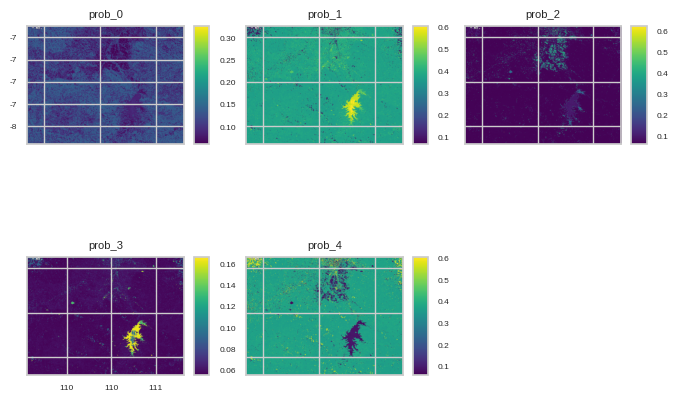

In [ ]:
result_xgb.plot()
plt.show()

In [ ]:
result_xgb.write(r"xgboost_lulc2.tif")

Raster Object Containing 5 Layers
    attribute                                             values
0       names           [prob_0, prob_1, prob_2, prob_3, prob_4]
1       files  [xgboost_lulc2.tif, xgboost_lulc2.tif, xgboost...
2        rows                                               1967
3        cols                                               2613
4         res   (0.00026949458523585647, 0.00026949458523585647)
5  nodatavals  [-3.4028234663852886e+38, -3.4028234663852886e...
